In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import umap
import joblib
from gensim.models.doc2vec import Doc2Vec
from gensim.models.fasttext import FastText
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from stemmer import AMSTokenizer, Stemmer, tokenize

/home/fahmi/freelance/project-2023-amsearch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import scienceplots
# plt.style.use(["ieee", "no-latex"])
# plt.rcParams["figure.dpi"] = 300

## Data Loading

In [3]:
df_queries = pd.read_json("../data/cleaned/queries.jsonl", lines=True)
df_queries.head()

,_id,text
0,99b78da2-54b4-4afa-b4c8-06df0dfb53d8,Holland Indonésé Festival di Bogor
1,42a37e80-e810-4813-a551-09dcbd471fa6,apa tujuan festival budaya di Bogor
2,5a0b9395-c28a-4c33-b5cc-5c502ee78790,siapa wakil duta besar Walanda
3,b821e85d-a6c3-4413-a0ba-d09ab1b72c2a,hubungan antara Indonésé jeung Walanda
4,37959229-85cc-432d-97e4-b437002efb17,acara naon anu dipidangkeun di festival


In [4]:
stemmer = Stemmer("../data/sundabaru1-vocab.txt")

def stem_sentence(text: str) -> str:
    return " ".join([stemmer.stem_ams(t) for t in tokenize(text)])

In [5]:
query_sentences = [stem_sentence(x) for x in df_queries["text"].values]
len(query_sentences)

11612

## Embeddings

In [19]:
def generate_embeddings(model_name: str, data: list[str]) -> np.ndarray:
    print(f"Embedding: {model_name}")

    if "bow" in model_name or "tfidf" in model_name:
        model = joblib.load(model_name)
        if "stem" in model_name:
            model.tokenizer = AMSTokenizer(stemmer)

        return np.asarray(model.transform(data).todense().astype(float))
    
    elif "doc2vec" in model_name:
        model = Doc2Vec.load(model_name)
        return np.array([model.infer_vector(tokenize(sentence)) for sentence in data]).astype(float)
    
    elif "fasttext" in model_name:
        model = FastText.load(model_name)
        return np.array([model.wv.get_sentence_vector(sentence) for sentence in data]).astype(float)
    
    elif "cos" in model_name or "mpnet" in model_name:
        model = SentenceTransformer(model_name)
        return model.encode(data, batch_size=16)
    
    else:
        raise ValueError("Invalid model name")


In [ ]:
embeddings = {
    "bow": generate_embeddings("../models/ams-bow-stem.joblib", query_sentences),
    "tfidf": generate_embeddings("../models/ams-tfidf-stem.joblib", query_sentences),
    "doc2vec": generate_embeddings("../models/ams-doc2vec-stem.gensim", query_sentences),
    "fasttext": generate_embeddings("../models/ams-fasttext-stem.gensim", query_sentences),
    "bert": generate_embeddings("../models/ams-multi-qa-distilbert-cos-v1-stem", query_sentences),
}

Embedding: ../models/ams-bow-stem.joblib
Embedding: ../models/ams-tfidf-stem.joblib
Embedding: ../models/ams-doc2vec-stem.gensim
Embedding: ../models/ams-fasttext-stem.gensim
Embedding: ../models/ams-multi-qa-distilbert-cos-v1


## Visualization

In [42]:
reducer = umap.UMAP()
umap_embeddings = reducer.fit_transform(embeddings["fasttext"])

umap_embeddings.shape

/home/fahmi/freelance/project-2023-amsearch/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(11612, 2)

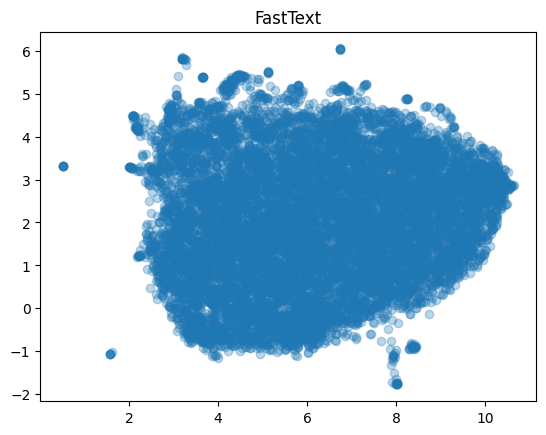

In [43]:
fig, ax = plt.subplots()

ax.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], alpha=0.3)
ax.set_title("FastText")

plt.show()

In [39]:
df_umap = pd.DataFrame({
    "x": umap_embeddings[:, 0],
    "y": umap_embeddings[:, 1],
    "query": query_sentences
})

df_umap.to_csv("embeddings-bert.csv", index=None)